# Create a Re-Act Agent graph using llms , tools 

## Goal:
    - Chat model decides to call the tool
    - agent output is chat model response
    - pass that ToolMessage back to the model
    - 
<img src="../Images/agent_nodes.png" width="500" height="500">

## General Agent Architechture

    act - let the model call specific tools
    observe - pass the tool output back to the model
    reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

In [1]:
# load api key
from dotenv import load_dotenv
import os

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"

In [2]:
from google import genai

#client = genai.client(api_key = os.environ["GOOGLE_API_KEY"])
client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-flash-lite-latest",
    temperature=0.2
)

result = llm.invoke("Hi, What day is this?")
print(result.content)

[{'type': 'text', 'text': 'Today is **Tuesday, May 21, 2024**.', 'extras': {'signature': 'EjQKMgEMOdbHkERI+aGRYh7TZCZZ9Kg9mPR/UAs/KkZRMhCTUUaQrpl9+0ShM8ZSpT81cMlr'}}]


## Create multiple arithmatic tools along with classifier tool

#### Addition
#### Substraction
#### Division
#### Check if the result is even or odd



In [4]:
#1.  Addition tool
def addition(a:float , b:float)->float :
    "add two numbers a and b "
    return a+b

#2. multiplication
def multiply(a:float , b:float)-> float:
    "multiply two numbers a and b "
    return a * b

# 3. division
def division(a:float , b:float)-> float:
    "divide number a by b"
    return a/b
# 4. check if number is even or odd
def check_evenOdd(num:float)->float:
    "Check if the number is even or odd"
    if num % 2 == 0 :
        return "even"
    return "Odd"
tools = [addition , multiply , division , check_evenOdd]

## Bind tool to the llm
### set parallel_tool_calls=False

In [5]:
tools_with_llm = llm.bind_tools(tools)


In [6]:
# check if tools work with llm
# Test

result = tools_with_llm.invoke("what tools are at your disposal?")
result.content[0]['text']

'I have access to a set of tools that allow me to perform calculations and logical checks. Specifically, I can:\n\n*   **Perform basic arithmetic:**\n    *   **Addition:** Add two numbers together.\n    *   **Multiplication:** Multiply two numbers.\n    *   **Division:** Divide one number by another.\n*   **Perform logical checks:**\n    *   **Even/Odd Check:** Determine if a given number is even or odd.\n\nIf you have a task that involves these operations, feel free to ask!'

## Create a MessagesState and Graph

In [7]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage , SystemMessage 

# set system message

sys_message = SystemMessage(content= " You are a helpful assistant who can perform arithmatic operations on set of inputs given. Follow the instructions given and if information is not clear, ask for more details. Use tools in any order as suited")

# set llm assistant

def llm_assistant(state:MessagesState) :
    response = tools_with_llm.invoke([sys_message] + state['messages'])
    print(f"(LLM_Response : {response}")
    return {'messages' : [response]}

## Use built in ToolNode and tools_condition
## create a graph



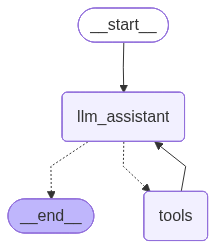

In [8]:
from langgraph.graph import START , END , StateGraph
from langgraph.prebuilt import ToolNode , tools_condition
from IPython.display import Image, display

# Build graph
builder = StateGraph(MessagesState)

# add nodes
builder.add_node('llm_assistant' , llm_assistant)
builder.add_node('tools' , ToolNode(tools))


# Define edges: determine how the control flow moves

builder.add_edge(START , 'llm_assistant')
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
builder.add_conditional_edges("llm_assistant" , tools_condition , {'tools': 'tools' , END :END })
builder. add_edge('tools', 'llm_assistant')

graph = builder.compile()
graph

## invoke graph

In [9]:
result = graph.invoke({'messages' : [HumanMessage( Role ='User' , content="What can you do?" , name = 'Diya')]})

(LLM_Response : content=[{'type': 'text', 'text': "I can help you with various arithmetic operations and basic number analysis. Specifically, I can:\n\n*   **Add** two numbers.\n*   **Multiply** two numbers.\n*   **Divide** one number by another.\n*   **Check** if a number is even or odd.\n\nIf you have a calculation you'd like me to perform, just let me know the numbers and the operation you need!", 'extras': {'signature': 'EjQKMgEMOdbHvK90fbccaClGq1Xwwekz7Wq6YwjLHJCTwNzr9TojPrH1ItZjf0cE9N3rgZUR'}}] additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019d9768-4cfa-7710-bf5f-5126758d1588-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 251, 'output_tokens': 87, 'total_tokens': 338, 'input_token_details': {'cache_read': 0}}


In [10]:
result = graph.invoke({'messages' : [HumanMessage( Role ='User' , content="Add the numbers 25 and 50 ,  divide the result by 10 and then multiply the output by 20 and check if the result is even" , name = 'Diya')]}, config={"run_name": "agent_test"})
result

(LLM_Response : content=[] additional_kwargs={'function_call': {'name': 'addition', 'arguments': '{"a": 25, "b": 50}'}, '__gemini_function_call_thought_signatures__': {'221ab9ff-1044-4fb0-8b81-1ec1d5d5040b': 'EjQKMgEMOdbHkAfN5JwFV1JpCTZCu9CkK5h5JnPhp/fTKgeA1SoAUYkVYCpvwPwRW5LALnsB'}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019d9768-5143-7731-a78c-ee9d8cbe1ad3-0' tool_calls=[{'name': 'addition', 'args': {'a': 25, 'b': 50}, 'id': '221ab9ff-1044-4fb0-8b81-1ec1d5d5040b', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 281, 'output_tokens': 18, 'total_tokens': 299, 'input_token_details': {'cache_read': 0}}
(LLM_Response : content=[] additional_kwargs={'function_call': {'name': 'division', 'arguments': '{"b": 10, "a": 75}'}, '__gemini_function_call_thought_signatures__': {'c55d5be5-3a84-4edf-a584-fb3de06d2f78': 'EjQKMgEMOdbHZDaPJTPG/BoeywXr/qqzSJm

{'messages': [HumanMessage(content='Add the numbers 25 and 50 ,  divide the result by 10 and then multiply the output by 20 and check if the result is even', additional_kwargs={}, response_metadata={}, name='Diya', id='77b2d4d4-223d-4a15-a052-2a59855ee2f8', Role='User'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'addition', 'arguments': '{"a": 25, "b": 50}'}, '__gemini_function_call_thought_signatures__': {'221ab9ff-1044-4fb0-8b81-1ec1d5d5040b': 'EjQKMgEMOdbHkAfN5JwFV1JpCTZCu9CkK5h5JnPhp/fTKgeA1SoAUYkVYCpvwPwRW5LALnsB'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d9768-5143-7731-a78c-ee9d8cbe1ad3-0', tool_calls=[{'name': 'addition', 'args': {'a': 25, 'b': 50}, 'id': '221ab9ff-1044-4fb0-8b81-1ec1d5d5040b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 281, 'output_tokens': 18, 'total_tokens': 299, 'input_token

In [11]:
result

{'messages': [HumanMessage(content='Add the numbers 25 and 50 ,  divide the result by 10 and then multiply the output by 20 and check if the result is even', additional_kwargs={}, response_metadata={}, name='Diya', id='77b2d4d4-223d-4a15-a052-2a59855ee2f8', Role='User'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'addition', 'arguments': '{"a": 25, "b": 50}'}, '__gemini_function_call_thought_signatures__': {'221ab9ff-1044-4fb0-8b81-1ec1d5d5040b': 'EjQKMgEMOdbHkAfN5JwFV1JpCTZCu9CkK5h5JnPhp/fTKgeA1SoAUYkVYCpvwPwRW5LALnsB'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d9768-5143-7731-a78c-ee9d8cbe1ad3-0', tool_calls=[{'name': 'addition', 'args': {'a': 25, 'b': 50}, 'id': '221ab9ff-1044-4fb0-8b81-1ec1d5d5040b', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 281, 'output_tokens': 18, 'total_tokens': 299, 'input_token

In [12]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================
Name: Diya

Add the numbers 25 and 50 ,  divide the result by 10 and then multiply the output by 20 and check if the result is even
================================== Ai Message ==================================

[]
Tool Calls:
  addition (221ab9ff-1044-4fb0-8b81-1ec1d5d5040b)
 Call ID: 221ab9ff-1044-4fb0-8b81-1ec1d5d5040b
  Args:
    a: 25
    b: 50
================================= Tool Message =================================
Name: addition

75.0
================================== Ai Message ==================================

[]
Tool Calls:
  division (c55d5be5-3a84-4edf-a584-fb3de06d2f78)
 Call ID: c55d5be5-3a84-4edf-a584-fb3de06d2f78
  Args:
    b: 10
    a: 75
================================= Tool Message =================================
Name: division

7.5
================================== Ai Message ==================================

[]
Tool Calls:
  multiply (f6a7ab2a-3d32-47b7-b4a5-93c97c8

# set Langchain tracing

In [13]:
os.environ['LANGCHAIN_PROJECT'] = 'langGraph-Course'